# Non-linear model

In [1]:
import os
# Import necessary libraries
import pickle  # For serializing and deserializing Python objects
import torch  # PyTorch for deep learning
import torch.nn as nn  # Neural network modules
import torch.nn.functional as F  # Functions for neural networks
import torch.optim  # Optimizers for training
from torch.utils.data import Dataset, DataLoader, TensorDataset  # Data handling utilities
from sklearn.model_selection import train_test_split  # Splitting data into training and testing sets

In [2]:
from sklearn.metrics import r2_score  # For calculating R-squared score
import pandas as pd  # Data manipulation and analysis
import math  # Mathematical functions
import numpy as np  # Numerical computations
from tqdm import tqdm  # Progress bar for loops
import polars as pl  # Alternative to pandas for dataframes
from collections import OrderedDict  # Ordered dictionary for maintaining insertion order
import sys  # System-specific parameters and functions
# from tabm_reference import Model, make_parameter_groups  # Custom model and utility functions
import warnings  # For suppressing warnings
warnings.filterwarnings("ignore")  # Ignore all warnings

In [3]:

import joblib  # For saving and loading Python objects
import gc
import warnings

## Lightgbm Model

### Preprocessing

In [4]:
from matplotlib import pyplot as plt
import matplotlib.cm as cm
from sklearn.model_selection import StratifiedGroupKFold

### Configurations

In [5]:
class CONFIG:  
    target_col = "responder_6"  
    lag_cols_original = ["date_id", "symbol_id"] + [f"responder_{idx}" for idx in range(9)]  
    lag_cols_rename = {f"responder_{idx}": f"responder_{idx}_lag_1" for idx in range(9)}  
    valid_ratio = 0.05  
    start_dt = 1100  

In [6]:
data2 = pl.read_parquet('processed_data/Processed_data_1695.parquet').select(
    pl.int_range(pl.len(), dtype=pl.UInt32).alias("id"),
    pl.all(),
).with_columns(
    (pl.col(CONFIG.target_col)*2).cast(pl.Int32).alias("label"),
).filter(
    pl.col("date_id").gt(CONFIG.start_dt)
)
print(data2)  

shape: (150_040, 94)
┌────────┬─────────┬─────────┬───────────┬───┬─────────────┬─────────────┬─────────────┬───────┐
│ id     ┆ date_id ┆ time_id ┆ symbol_id ┆ … ┆ responder_6 ┆ responder_7 ┆ responder_8 ┆ label │
│ ---    ┆ ---     ┆ ---     ┆ ---       ┆   ┆ ---         ┆ ---         ┆ ---         ┆ ---   │
│ u32    ┆ i16     ┆ i16     ┆ i8        ┆   ┆ f32         ┆ f32         ┆ f32         ┆ i32   │
╞════════╪═════════╪═════════╪═══════════╪═══╪═════════════╪═════════════╪═════════════╪═══════╡
│ 0      ┆ 1695    ┆ 0       ┆ 0         ┆ … ┆ 0.167316    ┆ -1.281933   ┆ -0.084505   ┆ 0     │
│ 1      ┆ 1695    ┆ 0       ┆ 1         ┆ … ┆ 0.730008    ┆ -1.589878   ┆ 0.265547    ┆ 1     │
│ 2      ┆ 1695    ┆ 0       ┆ 2         ┆ … ┆ -1.758799   ┆ 2.506598    ┆ -2.090755   ┆ -3    │
│ 3      ┆ 1695    ┆ 0       ┆ 3         ┆ … ┆ -0.055909   ┆ -0.570931   ┆ -0.120065   ┆ 0     │
│ 4      ┆ 1695    ┆ 0       ┆ 4         ┆ … ┆ 0.532245    ┆ 0.483285    ┆ -0.17336    ┆ 1     │
│ …      

This process is done to create lagged features for the dataset, enabling the model to use information from previous time steps to predict future outcomes. Lagging the features by one day shifts the data to align past values with the corresponding current observation, which is crucial for capturing temporal dependencies in time-series or sequential data. Renaming the lagged columns helps in maintaining clarity and avoiding confusion with the original features. Grouping by `"date_id"` and `"symbol_id"` and selecting the last record ensures that only the most relevant lagged data is used for each combination of date and symbol, making the feature engineering process precise and consistent.

In [7]:
lags = data2.select(pl.col(CONFIG.lag_cols_original))
lags = lags.rename(CONFIG.lag_cols_rename)
lags = lags.with_columns(
    date_id = pl.col('date_id') + 1,  # lagged by 1 day
    )
lags = lags.group_by(["date_id", "symbol_id"], maintain_order=True).last()  # pick up last record of previous date
lags

date_id,symbol_id,responder_0_lag_1,responder_1_lag_1,responder_2_lag_1,responder_3_lag_1,responder_4_lag_1,responder_5_lag_1,responder_6_lag_1,responder_7_lag_1,responder_8_lag_1
i16,i8,f32,f32,f32,f32,f32,f32,f32,f32,f32
1696,0,0.294176,0.354152,0.667191,-0.04351,-0.014215,0.325898,-0.161486,-0.03037,-0.280432
1696,1,-0.366702,-0.068075,0.441578,0.112738,0.029908,0.259045,-0.068422,-0.008499,-0.175012
1696,2,-0.052623,0.329514,-0.942705,-0.957935,-0.682461,-0.016045,0.698179,0.332717,0.899368
1696,3,-0.121472,-0.131891,0.758134,-0.112565,-0.039669,0.665049,0.023103,0.045357,0.026622
1696,4,-0.556568,-0.587054,1.478711,0.509851,0.265866,0.406741,0.0336,0.046135,0.030203
…,…,…,…,…,…,…,…,…,…,…
1699,34,0.243475,0.166927,0.38494,-0.174297,-0.066046,-0.038767,-0.132337,-0.022426,-0.252461
1699,35,0.850152,0.909382,1.015314,0.235962,0.122539,0.099559,-0.249584,-0.123571,-0.46063
1699,36,0.395684,-0.292574,-3.215846,-0.535129,-0.178484,-1.80815,-0.065355,-0.000367,-0.12517


In [8]:
data2 = data2.join(lags, on=["date_id", "symbol_id"],  how="left")
data2

id,date_id,time_id,symbol_id,weight,feature_00,feature_01,feature_02,feature_03,feature_04,feature_05,feature_06,feature_07,feature_08,feature_09,feature_10,feature_11,feature_12,feature_13,feature_14,feature_15,feature_16,feature_17,feature_18,feature_19,feature_20,feature_21,feature_22,feature_23,feature_24,feature_25,feature_26,feature_27,feature_28,feature_29,feature_30,feature_31,…,feature_61,feature_62,feature_63,feature_64,feature_65,feature_66,feature_67,feature_68,feature_69,feature_70,feature_71,feature_72,feature_73,feature_74,feature_75,feature_76,feature_77,feature_78,responder_0,responder_1,responder_2,responder_3,responder_4,responder_5,responder_6,responder_7,responder_8,label,responder_0_lag_1,responder_1_lag_1,responder_2_lag_1,responder_3_lag_1,responder_4_lag_1,responder_5_lag_1,responder_6_lag_1,responder_7_lag_1,responder_8_lag_1
u32,i16,i16,i8,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f64,f64,f64,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,…,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,i32,f32,f32,f32,f32,f32,f32,f32,f32,f32
0,1695,0,0,3.373552,2.776059,1.035769,1.790385,1.915069,1.765592,-0.105391,-0.16963,-0.345125,0.03763,11.0,7.0,76.0,-1.029333,0.271748,-0.640703,-0.688929,-0.763758,-0.664928,-1.701001,-1.246213,1.171051,-0.151066,1.780195,0.592178,2.011824,1.034978,1.035668,1.118305,0.616451,-0.932135,-1.078001,-0.154166,…,1.419774,-0.401114,-0.292407,-0.196831,-1.569348,-2.423477,-0.725855,0.203034,-0.451438,-0.841593,0.31118,-0.575253,0.171726,0.140167,1.225793,0.929635,0.067034,0.06966,-0.106951,-0.133057,0.037213,0.094861,-1.123129,-0.055226,0.167316,-1.281933,-0.084505,0,null,null,null,null,null,null,null,null,null
1,1695,0,1,2.802384,1.901147,1.029203,2.146977,2.811388,1.423654,-0.105936,-0.173366,-0.382062,0.045153,11.0,7.0,76.0,-1.263074,0.253009,-0.599086,-0.688929,-0.633995,-0.664928,-1.906501,-0.91079,0.886705,0.012082,1.116906,0.85608,1.12455,0.723127,-1.920028,-0.053758,1.010441,-0.559132,-0.940507,0.010087,…,1.419774,-0.49611,-0.439725,-0.442559,-1.185965,-1.933517,-1.124566,0.131424,-0.604832,-0.760508,0.142326,-0.745543,0.171726,0.140167,-0.226083,-0.213198,-0.206452,-0.373929,-0.443276,-0.326311,-0.234482,0.262298,-1.037623,0.010625,0.730008,-1.589878,0.265547,1,null,null,null,null,null,null,null,null,null
2,1695,0,2,2.506616,2.801315,1.376992,2.313733,2.135918,1.765473,-0.173767,-0.261385,-0.473618,0.018804,81.0,2.0,59.0,-0.99006,0.873093,-0.564999,-0.688929,-0.389982,-0.664928,-1.932154,-0.971507,0.023837,-0.145004,0.877403,0.370831,0.23665,-0.146222,0.580706,0.660125,0.125094,-0.627553,-0.784622,-0.183313,…,1.419774,-0.363737,-0.314952,-0.355761,-1.836319,-1.781683,-0.99552,-0.030046,-0.476795,-0.888185,1.50716,-0.264173,0.171726,0.140167,1.517169,1.503251,0.094979,0.109544,0.351735,0.075186,0.683174,-1.139817,1.508688,-1.052497,-1.758799,2.506598,-2.090755,-3,null,null,null,null,null,null,null,null,null
3,1695,0,3,1.868808,2.492323,1.293729,2.051276,2.601039,2.115296,-0.137015,-0.15458,-0.39843,0.058264,4.0,3.0,11.0,-1.047425,1.116742,-0.303803,-0.688929,-0.510801,-0.664928,-1.360154,-1.818448,-0.282608,-0.068771,0.591393,0.9088,0.051669,-0.261807,-0.01116,-0.169174,-0.219266,-0.642355,-0.530943,-0.037706,…,1.419774,-0.315971,-0.243883,-0.276656,-2.015491,-2.266636,-1.011813,0.711239,-0.346282,-1.06627,0.20662,-0.518951,0.171726,0.140167,0.425632,0.424689,-0.129259,-0.146268,0.047888,-0.01461,-0.334644,-0.0426,-0.569183,-0.244618,-0.055909,-0.570931,-0.120065,0,null,null,null,null,null,null,null,null,null
4,1695,0,4,2.826087,2.754668,0.981692,2.405406,2.504181,2.060546,-0.067486,-0.153702,-0.205151,0.021181,15.0,1.0,9.0,-0.840723,1.097859,-0.419687,-0.688929,-0.834465,-0.664928,-1.323989,-1.13767,-1.158483,0.721674,0.600382,0.503107,3.989845,2.300339,-1.061703,-1.456307,-0.602596,-0.788082,-1.124169,0.471126,…,1.419774,-0.636202,-0.459555,-0.389831,-1.187485,-1.30136,-0.830222,0.3195

By determining the total number of records and calculating the number of validation records, it ensures that a fixed proportion of the data is reserved for validation to evaluate the model's performance. The remaining data is allocated for training. The calculation of `last_tr_dt` identifies the latest training date, which serves as a cutoff point for splitting the data into training and validation sets, ensuring temporal consistency in the split for time-series or sequential modeling.

In [21]:
# Set the ratio for train and validation split  
train_ratio = 0.8  

# Calculate dataset size and the split indices  
len_data = data2.select(pl.col("date_id")).shape[0]  
train_records = int(len_data * train_ratio)  
valid_records = len_data - train_records  

# Determine the splitting threshold date  
split_tr_dt = data2.select(pl.col("date_id")).row(train_records)[0]  

# Print details for clarity  
print(f"\n len_data   = {len_data}")  
print(f"\n train_records = {train_records}")  
print(f"\n valid_records = {valid_records}")  
print(f"\n---> Split threshold date = {split_tr_dt}\n")  

# Split the dataset into train and validation sets  
train = data2.filter(pl.col("date_id").le(split_tr_dt-1))  
valid = data2.filter(pl.col("date_id").gt(split_tr_dt-1))


 len_data   = 150040

 train_records = 120032

 valid_records = 30008

---> Split threshold date = 1698



In [22]:
train.shape, valid.shape

((112288, 103), (37752, 103))

In [23]:
valid

id,date_id,time_id,symbol_id,weight,feature_00,feature_01,feature_02,feature_03,feature_04,feature_05,feature_06,feature_07,feature_08,feature_09,feature_10,feature_11,feature_12,feature_13,feature_14,feature_15,feature_16,feature_17,feature_18,feature_19,feature_20,feature_21,feature_22,feature_23,feature_24,feature_25,feature_26,feature_27,feature_28,feature_29,feature_30,feature_31,…,feature_61,feature_62,feature_63,feature_64,feature_65,feature_66,feature_67,feature_68,feature_69,feature_70,feature_71,feature_72,feature_73,feature_74,feature_75,feature_76,feature_77,feature_78,responder_0,responder_1,responder_2,responder_3,responder_4,responder_5,responder_6,responder_7,responder_8,label,responder_0_lag_1,responder_1_lag_1,responder_2_lag_1,responder_3_lag_1,responder_4_lag_1,responder_5_lag_1,responder_6_lag_1,responder_7_lag_1,responder_8_lag_1
u32,i16,i16,i8,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f64,f64,f64,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,…,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,i32,f32,f32,f32,f32,f32,f32,f32,f32,f32
112288,1698,0,0,3.743546,2.309442,1.404777,2.052407,1.860581,0.004939,0.188701,0.197857,0.082196,-0.130009,11.0,7.0,76.0,-0.877468,0.66075,-0.303573,-1.010704,-0.813168,-1.088203,-1.710606,-1.36424,1.515887,-0.202102,1.285443,0.787999,1.921844,1.28118,1.223592,1.002706,0.587736,-0.643336,-0.943377,-0.148149,…,-1.101531,-0.518554,-0.324163,-0.393839,-1.251833,-1.461797,-0.867715,0.279538,-0.34136,-0.765203,0.423838,-0.355171,-0.270193,-0.257476,0.801169,0.69798,0.008923,0.010417,-0.442215,-0.322407,0.143594,-0.92689,-0.782236,-0.036595,-1.305746,-0.795677,-0.143724,-2,-0.188392,0.053455,-0.167253,-0.091034,-0.07965,-0.234954,-0.014667,0.021698,-0.037189
112289,1698,0,1,2.826357,2.046231,1.634353,1.32978,1.441716,-0.20124,0.270867,0.282076,0.11134,-0.147423,11.0,7.0,76.0,-0.797314,-0.177849,-0.583759,-0.755989,-0.518747,-0.852021,-1.047215,-1.435203,1.280485,-0.024357,0.936136,1.288942,0.845199,0.516642,-1.466948,0.035089,1.195631,-0.671953,-0.648468,-0.030753,…,-1.101531,-0.384534,-0.264305,-0.334309,-1.310108,-1.837694,-0.710028,-0.092546,-0.543664,-0.921565,-0.224318,-0.707887,-0.278324,-0.22939,0.105722,0.126959,-0.165226,-0.130599,-0.651829,-1.70784,-0.893942,-1.065488,-1.871338,-0.615652,-1.162801,-1.205924,-1.245934,-2,0.420137,0.288236,-0.158652,0.087689,0.034765,-0.014719,-0.0881,-0.008677,-0.174111
112290,1698,0,2,3.120292,1.885471,1.183647,1.501341,1.861803,-0.034465,0.476829,0.354726,0.166955,-0.104411,81.0,2.0,59.0,-0.734696,0.202958,-0.686141,-0.777122,-0.448477,-0.611837,-1.156676,-1.350384,0.080837,-0.174716,1.078999,0.448147,0.117895,-0.68001,0.717676,0.83595,0.450227,-0.789566,-0.666649,-0.17165,…,-1.101531,-0.257202,-0.313653,-0.299827,-1.573021,-2.059235,-0.886751,0.241406,-0.489898,-0.973302,0.071241,-0.664589,-0.429859,-0.259806,0.441188,0.430596,-0.150894,-0.116166,-0.656373,-0.264575,-0.892879,-1.511886,-1.03348,-0.378265,-1.57429,-1.863071,-0.027343,-3,-0.127444,0.233288,0.019294,-0.066573,-0.029141,-1.220034,-0.373827,-0.25904,-1.286049
112291,1698,0,3,2.638314,1.946201,0.473077,1.512463,2.250226,-0.000911,0.255018,0.357259,0.107071,-0.199885,4.0,3.0,11.0,-0.945209,1.440261,-0.372922,-0.806556,-0.477212,-0.770526,-2.148908,-0.722694,-0.185432,-0.032784,0.513848,0.911167,0.1399,-0.494777,-0.010124,-0.061895,-0.303735,-0.851368,-0.481167,-0.043368,…,-1.101531,-0.360943,-0.153755,-0.260567,-1.992604,-1.955231,-0.858589,0.61958,-0.323356,-0.616397,1.519202,-0.268978,-0.163753,-0.143235,0.024091,0.020998,-0.205226,-0.182941,-0.188186,-0.19097,-0.70149,0.098453,-1.015506,-0.054984,0.329152,-0.965471,0.576635,0,0.787691,0.522771,0.417465,0.045374,0.031438,-0.159561,-0.171348,-0.064907,-0.420551
112292,1698,0,4,1.852919,1.502017,0.926709,2.511769,2.168552,-0.224433,0.098944,0.136531,0.065738,-0.072156,15.0,1.0,9.0,-0.77903,0.242692,-0.636916,-1.140989,-0.602013,-1.043103,-

### Training Model

In [24]:
from tqdm.auto import tqdm
from sklearn.metrics import r2_score
from lightgbm import LGBMRegressor
import lightgbm as lgb
# from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from sklearn.ensemble import VotingRegressor
from sklearn.metrics import mean_squared_error 

In [25]:
class CONFIG:
    seed = 42
    target_col = "responder_6"
    feature_cols = ["symbol_id", "time_id"] \
        + [f"feature_{idx:02d}" for idx in range(79)] \
        + [f"responder_{idx}_lag_1" for idx in range(9)]
    categorical_cols = []

In [26]:
X_train = train[CONFIG.feature_cols].to_pandas()
y_train = train[CONFIG.target_col].to_pandas().squeeze() 
w_train = train["weight"].to_pandas().squeeze() 

X_valid = valid[CONFIG.feature_cols].to_pandas()
y_valid = valid[CONFIG.target_col].to_pandas().squeeze() 
w_valid = valid["weight"].to_pandas().squeeze() 

X_train.shape, y_train.shape, w_train.shape, X_valid.shape, y_valid.shape, w_valid.shape

((112288, 90), (112288,), (112288,), (37752, 90), (37752,), (37752,))

In [29]:
# # Define the LightGBM model and optimize the parameters  
model = lgb.LGBMRegressor(  
    boosting_type='gbdt',  
    objective='regression',  
    device='gpu',                 # use GPU    
    n_estimators=120,  
    max_depth=10,  
    learning_rate=0.1,  
    subsample=0.8,                # Use 80% of the data for each iteration 
    colsample_bytree=0.6,         # Use 60% of the features for each iteration   
    num_leaves=64,                # The number of leaf nodes is 64 
    min_data_in_leaf=30,            
    random_state=CONFIG.seed,  
    verbose=-1                      
) 

In [31]:
model.fit(  
    X_train, y_train,  
    sample_weight=w_train,  
    eval_set=[(X_valid, y_valid)],  
    eval_sample_weight=[w_valid],  
    # early_stopping_rounds=10,  
    # verbose=50   
) 

LGBMRegressor(colsample_bytree=0.6, device='gpu', max_depth=10,
              min_data_in_leaf=30, n_estimators=120, num_leaves=64,
              objective='regression', random_state=42, subsample=0.8,
              verbose=-1)

In [32]:
y_pred = model.predict(X_valid)  
mse = mean_squared_error(y_valid, y_pred)  
print(f'均方误差 (MSE): {mse}')  

均方误差 (MSE): 0.7048139776838911


In [33]:
y_pred_valid = model.predict(X_valid)
valid_score = r2_score(y_valid, y_pred_valid, sample_weight=w_valid )
valid_score

-0.21029767246891118

In [34]:
train_pd = train[["symbol_id", CONFIG.target_col]].to_pandas()

y_means = { symbol_id : -1 for symbol_id in range(39) }
for symbol_id, gdf in train_pd.groupby("symbol_id"):
    y_mean = gdf[ CONFIG.target_col ].mean()
    y_means[symbol_id] = y_mean
    print(f"symbol_id = {symbol_id}, y_means = {y_mean:.5f}")

symbol_id = 0, y_means = -0.10912
symbol_id = 1, y_means = -0.04213
symbol_id = 2, y_means = 0.02820
symbol_id = 3, y_means = 0.03200
symbol_id = 4, y_means = 0.03237
symbol_id = 5, y_means = 0.01617
symbol_id = 6, y_means = 0.05731
symbol_id = 7, y_means = -0.09457
symbol_id = 8, y_means = 0.08269
symbol_id = 9, y_means = -0.03417
symbol_id = 10, y_means = 0.09159
symbol_id = 11, y_means = -0.01075
symbol_id = 12, y_means = 0.07491
symbol_id = 13, y_means = -0.03254
symbol_id = 14, y_means = 0.00336
symbol_id = 15, y_means = 0.02291
symbol_id = 16, y_means = -0.04743
symbol_id = 17, y_means = 0.01417
symbol_id = 18, y_means = 0.01308
symbol_id = 19, y_means = 0.10629
symbol_id = 20, y_means = -0.06529
symbol_id = 21, y_means = -0.02228
symbol_id = 22, y_means = 0.11640
symbol_id = 23, y_means = 0.00589
symbol_id = 24, y_means = 0.13448
symbol_id = 25, y_means = -0.05129
symbol_id = 26, y_means = 0.10864
symbol_id = 27, y_means = -0.00405
symbol_id = 28, y_means = 0.00820
symbol_id = 2

In [35]:
cv_detail = { symbol_id : 0 for symbol_id in range(39) }
valid_pd = valid.to_pandas()  # Convert polars DataFrame to pandas DataFrame
for symbol_id, gdf in valid_pd.groupby("symbol_id"):
    X_valid = gdf[ CONFIG.feature_cols ]
    y_valid = gdf[ CONFIG.target_col ]
    w_valid = gdf[ "weight" ]
    y_pred_valid = model.predict(X_valid)
    score = r2_score(y_valid, y_pred_valid, sample_weight=w_valid )
    cv_detail[symbol_id] = score

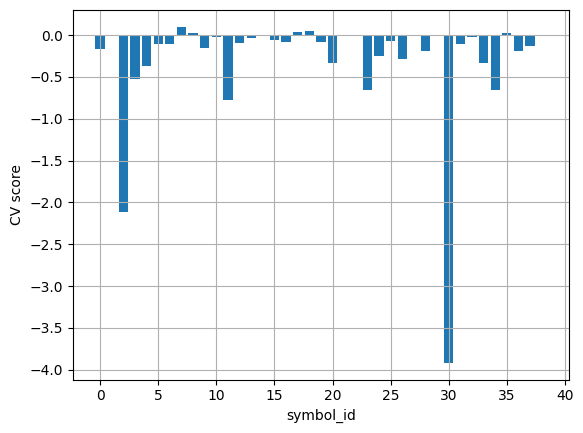

In [36]:
sids = list(cv_detail.keys())
plt.bar(sids, [cv_detail[sid] for sid in sids])
plt.grid()
plt.xlabel("symbol_id")
plt.ylabel("CV score")
plt.show()

In [37]:
result = {
    "model" : model,
    "cv" : valid_score,
    "cv_detail" : cv_detail,
    "y_mean" : y_means,
}
with open("result_1695.pkl", "wb") as fp:
    pickle.dump(result, fp)

## Bayesian Optimization 

In [38]:
from bayes_opt import BayesianOptimization  
from sklearn.metrics import mean_squared_error  
import lightgbm as lgb  

In [39]:
def train_lgbm(  
    learning_rate,   
    max_depth,   
    subsample,   
    colsample_bytree,   
    num_leaves,  
    min_data_in_leaf  
):  
    # Parameters converted to integers should be manually int(), otherwise an error will be reported  
    max_depth = int(max_depth)  
    num_leaves = int(num_leaves)  
    min_data_in_leaf = int(min_data_in_leaf)  
    
    # 创建模型  
    model = lgb.LGBMRegressor(  
        boosting_type='gbdt',  
        objective='regression',  
        device='gpu',  
        n_estimators=120,  
        random_state=CONFIG.seed, 
        # verbose=-1,  
        # 将可调参数替换为形参  
        learning_rate=learning_rate,  
        max_depth=max_depth,   
        subsample=subsample,  
        colsample_bytree=colsample_bytree,  
        num_leaves=num_leaves,  
        min_data_in_leaf=min_data_in_leaf  
    )  
    
    # Training 
    model.fit(  
        X_train, y_train,  
        sample_weight=w_train,  
        eval_set=[(X_valid, y_valid)],  
        eval_sample_weight=[w_valid],  
        # verbose=False 
    )  
    
    # Valid 
    y_pred_valid = model.predict(X_valid)  
    rmse = mean_squared_error(y_valid, y_pred_valid)   
    return -rmse  

In [40]:
def lgb_cv(learning_rate, num_leaves, max_depth,   
          min_child_samples, subsample,   
          colsample_bytree, reg_alpha, reg_lambda):  
    
    params = {  
        'objective': 'regression',       
        'metric': 'rmse',                
        'boosting_type': 'gbdt',  
        'learning_rate': learning_rate,  
        'num_leaves': int(num_leaves),   
        'max_depth': int(max_depth),  
        'min_child_samples': int(min_child_samples),  
        'subsample': subsample,  
        'colsample_bytree': colsample_bytree,  
        'reg_alpha': reg_alpha,  
        'reg_lambda': reg_lambda,  
        # 'verbose': -1  
    }  
  
    cv_results = lgb.cv(  
        params,  
        train_dataset,  
        nfold=5,  
        stratified=False,  
        num_boost_round=1000,  
        early_stopping_rounds=50,    
        seed=42  
    )  

    mean_rmse = np.min(cv_results['rmse-mean'])  
    return -mean_rmse  

In [41]:
pbounds = {  
    'learning_rate': (0.01, 0.2),  
    'max_depth': (3, 12),  
    'subsample': (0.6, 1.0),  
    'colsample_bytree': (0.6, 1.0),  
    'num_leaves': (32, 128),  
    'min_data_in_leaf': (10, 100)  
}  

optimizer = BayesianOptimization(  
    f=train_lgbm,  
    pbounds=pbounds,  
    random_state=42  
)  

# init_points指定初始随机探索的次数, n_iter指定之后的贝叶斯迭代次数  
optimizer.maximize(init_points=5, n_iter=20)  

|   iter    |  target   | colsam... | learni... | max_depth | min_da... | num_le... | subsample |
-------------------------------------------------------------------------------------------------
| 1         | -0.4762   | 0.7498    | 0.1906    | 9.588     | 63.88     | 46.98     | 0.6624    |
| 2         | -0.4265   | 0.6232    | 0.1746    | 8.41      | 73.73     | 33.98     | 0.988     |
| 3         | -0.4334   | 0.933     | 0.05034   | 4.636     | 26.51     | 61.21     | 0.8099    |
| 4         | -0.49     | 0.7728    | 0.06533   | 8.507     | 22.55     | 60.05     | 0.7465    |
| 5         | -0.4463   | 0.7824    | 0.1592    | 4.797     | 56.28     | 88.87     | 0.6186    |
| 6         | -0.4516   | 0.7708    | 0.08671   | 5.41      | 56.12     | 89.22     | 0.7673    |
| 7         | -0.4566   | 0.997     | 0.1881    | 9.877     | 71.74     | 35.4      | 0.8134    |
| 8         | -0.4475   | 0.8073    | 0.05515   | 8.254     | 75.64     | 32.87     | 0.6023    |
| 9         | -0.449

In [42]:
best_params = optimizer.max['params']  
print("最佳参数：", best_params)  
print("最佳目标函数值(负的RMSE)：", optimizer.max['target'])  

最佳参数： {'colsample_bytree': 0.6232334448672797, 'learning_rate': 0.1745734676972377, 'max_depth': 8.41003510568888, 'min_data_in_leaf': 73.7265320016441, 'num_leaves': 33.976111452397035, 'subsample': 0.9879639408647978}
最佳目标函数值(负的RMSE)： -0.42646722634209494


In [43]:
best_params['max_depth'] = int(best_params['max_depth'])  
best_params['num_leaves'] = int(best_params['num_leaves'])  
best_params['min_data_in_leaf'] = int(best_params['min_data_in_leaf'])  

final_model = lgb.LGBMRegressor(  
    boosting_type='gbdt',  
    objective='regression',  
    device='gpu',  
    n_estimators=120,  
    random_state=42,  
    # verbose=-1,  
    **best_params  
)  
final_model.fit(  
    X_train, y_train,  
    sample_weight=w_train,  
    eval_set=[(X_valid, y_valid)],  
    eval_sample_weight=[w_valid],  
    # verbose=True  
)  

LGBMRegressor(colsample_bytree=0.6232334448672797, device='gpu',
              learning_rate=0.1745734676972377, max_depth=8,
              min_data_in_leaf=73, n_estimators=120, num_leaves=33,
              objective='regression', random_state=42,
              subsample=0.9879639408647978)

In [44]:
y_pred = final_model.predict(X_valid)  
mse = mean_squared_error(y_valid, y_pred)  
print(f'均方误差 (MSE): {mse}')  

均方误差 (MSE): 0.4264672256907342


In [45]:
y_pred_valid = final_model.predict(X_valid)
valid_score = r2_score(y_valid, y_pred_valid, sample_weight=w_valid )
valid_score

-0.013773087543530016

In [46]:
cv_detail = { symbol_id : 0 for symbol_id in range(39) }
valid_pd = valid.to_pandas()  # Convert polars DataFrame to pandas DataFrame
for symbol_id, gdf in valid_pd.groupby("symbol_id"):
    X_valid = gdf[ CONFIG.feature_cols ]
    y_valid = gdf[ CONFIG.target_col ]
    w_valid = gdf[ "weight" ]
    y_pred_valid = final_model.predict(X_valid)
    score = r2_score(y_valid, y_pred_valid, sample_weight=w_valid )
    cv_detail[symbol_id] = score

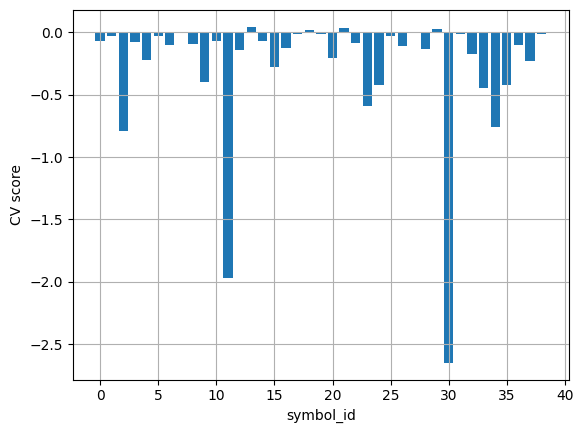

In [47]:
sids = list(cv_detail.keys())
plt.bar(sids, [cv_detail[sid] for sid in sids])
plt.grid()
plt.xlabel("symbol_id")
plt.ylabel("CV score")
plt.show()

In [49]:
result = {
    "model" : final_model,
    "cv" : valid_score,
    "cv_detail" : cv_detail,
    "y_mean" : y_means,
}
with open("Lightgbm_with_Bayesian_Optimization_1695.pkl", "wb") as fp:
    pickle.dump(result, fp)